# DataCo Smart Supply Chain — End-to-End Analysis

An exploratory and predictive analysis of ~180,000 orders from the [DataCo Smart Supply Chain dataset](https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis) (Kaggle).

**Business questions:**
1. What drives late deliveries, and can we predict them before they happen?
2. Which regions and product categories are most profitable?
3. How does order volume trend over time?

**Setup (packages ran in terminal):**
```
pip install pandas numpy matplotlib seaborn scikit-learn jupyter
```


In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter, StrMethodFormatter

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")
%matplotlib inline

## 1. Configuration

Update `DATA_DIR` below if your files live somewhere else.

In [22]:
DATA_DIR = r"C:\Projects\DataCo Project"
DATA_FILE = os.path.join(DATA_DIR, "data", "raw", "DataCoSupplyChainDataset.csv")

OUTPUT_DIR = os.path.join(DATA_DIR, "outputs")
CHARTS_DIR = os.path.join(OUTPUT_DIR, "charts")
os.makedirs(CHARTS_DIR, exist_ok=True)

## 2. Load Data

In [23]:
# The file uses Latin-1 encoding, not UTF-8 — this avoids a common read error
df = pd.read_csv(DATA_FILE, encoding="latin1")
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")
df.head()

Loaded 180,519 rows and 53 columns.


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## 3. Initial Inspection

In [24]:
df.isnull().sum().sort_values(ascending=False).head(10)

Product Description         180519
Order Zipcode               155679
Customer Lname                   8
Customer Zipcode                 3
Type                             0
Order Profit Per Order           0
Order Item Cardprod Id           0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Id                    0
dtype: int64

## 4. Clean Data

Drop PII, constant, or mostly-missing columns, important since this project will be shared publicly.

In [25]:
drop_cols = [
    "Customer Email", "Customer Password", "Customer Fname", "Customer Lname",
    "Customer Street", "Product Image", "Product Description", "Product Status",
    "Order Zipcode",  # mostly missing
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])

before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df):,} duplicate rows.")

Dropped 0 duplicate rows.


## 5. Feature Engineering

In [26]:
df["order_year"] = df["order date (DateOrders)"].dt.year
df["order_month"] = df["order date (DateOrders)"].dt.month
df["order_dow"] = df["order date (DateOrders)"].dt.day_name()

# Actual shipping delay = real days taken minus scheduled days
df["shipping_delay"] = df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]

# Profit margin per order
df["profit_margin"] = np.where(
    df["Sales per customer"] > 0,
    df["Benefit per order"] / df["Sales per customer"],
    np.nan
)

df[["order_year", "order_month", "order_dow", "shipping_delay", "profit_margin"]].head()

,order_year,order_month,order_dow,shipping_delay,profit_margin
0,2018,1,Wednesday,-1,0.290014
1,2018,1,Saturday,1,-0.800006
2,2018,1,Saturday,0,-0.800013
3,2018,1,Saturday,-1,0.074998
4,2018,1,Saturday,-2,0.449992


## 6. Exploratory Data Analysis

Each chart is saved as a PNG (for my LinkedIn post / GitHub README) and each summary table as a CSV (for Tableau import).

In [27]:
overall_late_rate = df["Late_delivery_risk"].mean()
print(f"Overall late delivery rate: {overall_late_rate:.1%}")

Overall late delivery rate: 54.8%


### Late delivery rate by shipping mode

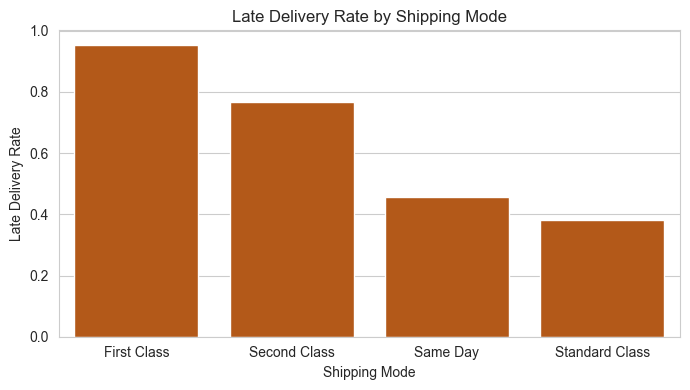

In [28]:
late_by_shipmode = (
    df.groupby("Shipping Mode")["Late_delivery_risk"]
    .mean()
    .sort_values(ascending=False)
    .rename("late_delivery_rate")
    .reset_index()
)
late_by_shipmode.to_csv(os.path.join(OUTPUT_DIR, "late_rate_by_shipping_mode.csv"), index=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=late_by_shipmode, x="Shipping Mode", y="late_delivery_rate", color="#CC5500")
plt.title("Late Delivery Rate by Shipping Mode")
plt.ylabel("Late Delivery Rate")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "late_rate_by_shipping_mode.png"), dpi=150)
plt.show()

### Late delivery rate by region

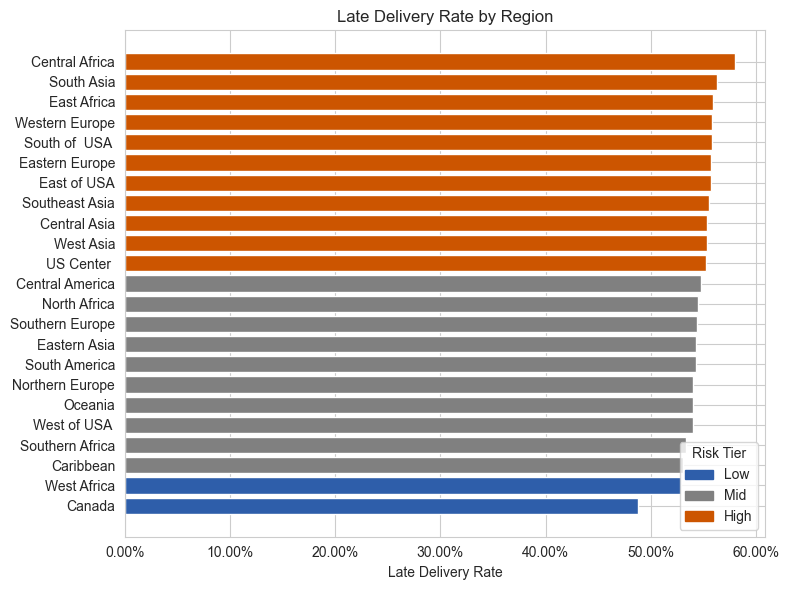

In [29]:
late_by_region = (
    df.groupby("Order Region")["Late_delivery_risk"]
    .mean()
    .sort_values(ascending=False)
    .rename("late_delivery_rate")
    .reset_index()
)
late_by_region.to_csv(os.path.join(OUTPUT_DIR, "late_rate_by_region.csv"), index=False)

# Bucket each region into a risk tier based on its late delivery rate
def assign_risk_tier(rate):
    if rate >= 0.55:
        return "High"
    elif rate >= 0.53:
        return "Mid"
    else:
        return "Low"

late_by_region["risk_tier"] = late_by_region["late_delivery_rate"].apply(assign_risk_tier)

# Low = blue, Mid = gray, High = burnt orange
tier_colors = {"Low": "#2E5EAA", "Mid": "#808080", "High": "#CC5500"}
bar_colors = late_by_region["risk_tier"].map(tier_colors)

plt.figure(figsize=(8, 6))
plt.barh(late_by_region["Order Region"], late_by_region["late_delivery_rate"], color=bar_colors)
plt.gca().invert_yaxis()  # keep highest rate at the top, matching the sorted order
plt.title("Late Delivery Rate by Region")
plt.xlabel("Late Delivery Rate")
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=2))

# Legend showing what each color/tier means
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in tier_colors.values()]
plt.legend(legend_handles, tier_colors.keys(), title="Risk Tier", loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "late_rate_by_region.png"), dpi=150)
plt.show()

### Profit by product category (top 15)

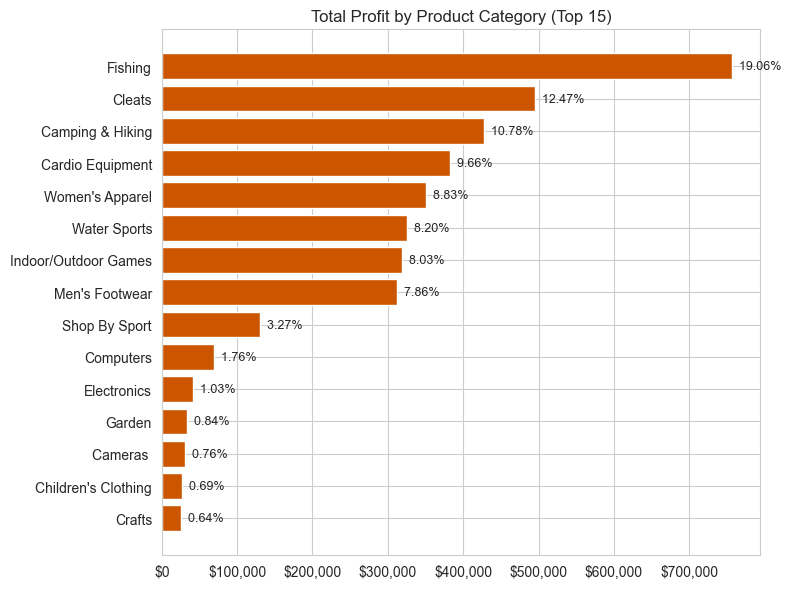

In [30]:
profit_by_category = (
    df.groupby("Category Name")["Order Profit Per Order"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .rename("total_profit")
    .reset_index()
)

# Each category's share of profit, out of the total across ALL categories
# (not just the top 15 shown), so the percentages reflect true company-wide share
grand_total_profit = df["Order Profit Per Order"].sum()
profit_by_category["pct_of_total"] = profit_by_category["total_profit"] / grand_total_profit

profit_by_category.to_csv(os.path.join(OUTPUT_DIR, "profit_by_category.csv"), index=False)

plt.figure(figsize=(8, 6))
bars = plt.barh(profit_by_category["Category Name"], profit_by_category["total_profit"], color="#CC5500")
plt.gca().invert_yaxis()  # highest-profit category at the top
plt.title("Total Profit by Product Category (Top 15)")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))

# Label each bar with its percentage share of total profit, 2 decimal places
for bar, pct in zip(bars, profit_by_category["pct_of_total"]):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {pct:.2%}",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "profit_by_category.png"), dpi=150)
plt.show()

### Order volume over time (initial pass)

A first look at monthly order volume, built directly from row counts.

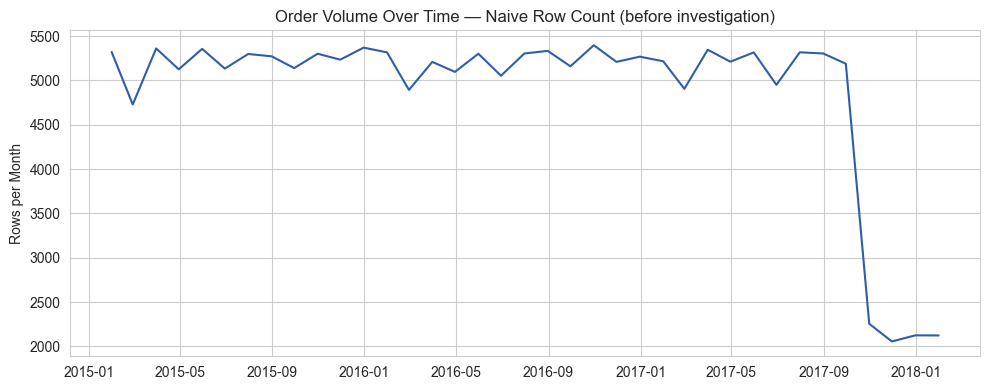

In [31]:
orders_over_time_naive = (
    df.set_index("order date (DateOrders)")
    .resample("ME")
    .size()
    .rename("row_count")
    .reset_index()
)
orders_over_time_naive.to_csv(os.path.join(OUTPUT_DIR, "orders_over_time_naive_rowcount.csv"), index=False)

plt.figure(figsize=(10, 4))
plt.plot(orders_over_time_naive["order date (DateOrders)"], orders_over_time_naive["row_count"], color="#2E5EAA")
plt.title("Order Volume Over Time — Naive Row Count (before investigation)")
plt.ylabel("Rows per Month")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "orders_over_time_naive.png"), dpi=150)
plt.show()

This chart shows a sharp drop in volume starting around October 2017, from roughly 5,200/month down to about 2,100/month, sustained through January 2018. Rather than taking that at face value as a real business decline, it's worth investigating what's actually being counted here.

### Data quality investigation

#### Step 1: Check whether the date field is really daily granularity

If `order date` were a true calendar date, the number of *distinct* date values in any given month could never exceed the number of days in that month (max 31). Checking this directly reveals whether the row count above is actually counting orders, calendar days, or something else.

In [32]:
distinct_datetimes_by_month = (
    df.groupby(df["order date (DateOrders)"].dt.to_period("M"))["order date (DateOrders)"]
    .nunique()
    .rename("distinct_order_datetimes")
    .reset_index()
)
distinct_datetimes_by_month.columns = ["month", "distinct_order_datetimes"]
distinct_datetimes_by_month.head(10)

,month,distinct_order_datetimes
0,2015-01,1787
1,2015-02,1585
2,2015-03,1781
3,2015-04,1710
4,2015-05,1776
5,2015-06,1725
6,2015-07,1763
7,2015-08,1762
8,2015-09,1706
9,2015-10,1775


The distinct count runs roughly 1,700-1,800 per month for most of the series far above 31, the maximum possible if this were a true calendar date. This confirms `order date` carries a full timestamp. So a plain row count isn't measuring "days with activity", and given the naive chart's ~5,000+/month row counts far exceed this too, it also isn't simply counting one row per order. Something else is going on with row granularity.

#### Step 2: Check the row-to-order ratio over time

If each order can generate multiple rows (e.g. one row per line item), the row count and the *distinct order* count will diverge. Tracking that ratio over time isolates exactly when and how the row granularity changes.

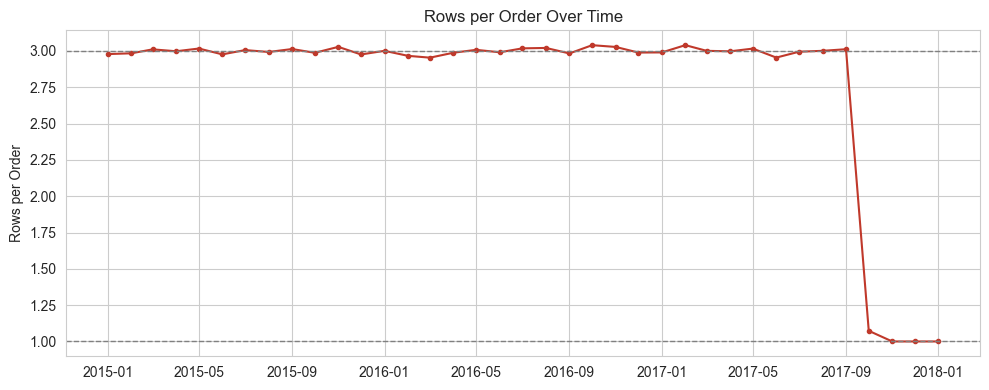

In [33]:
rows_per_order = (
    df.groupby(df["order date (DateOrders)"].dt.to_period("M"))["Order Id"]
    .agg(total_rows="count", distinct_orders="nunique")
    .reset_index()
)
rows_per_order.columns = ["month", "total_rows", "distinct_orders"]
rows_per_order["rows_per_order"] = rows_per_order["total_rows"] / rows_per_order["distinct_orders"]
rows_per_order["month_ts"] = rows_per_order["month"].dt.to_timestamp()

plt.figure(figsize=(10, 4))
plt.plot(rows_per_order["month_ts"], rows_per_order["rows_per_order"], color="#C0392B", marker="o", markersize=3)
plt.title("Rows per Order Over Time")
plt.ylabel("Rows per Order")
plt.axhline(1.0, color="gray", linestyle="--", linewidth=1)
plt.axhline(3.0, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "rows_per_order_over_time.png"), dpi=150)
plt.show()

The ratio holds at a clean, flat ~3.0 for most of the series, consistent with roughly three rows per order (one row per line item in a multi-item order). From there, the count steps sharply down to exactly 1.0 starting around September 2017 and holds flat through the end of the dataset (January 2018).

**This is the root cause of the "sharp drop."** It isn't a decline in business activity, it's a change in row granularity partway through the dataset: orders stopped being represented by multiple line-item rows and started being represented by exactly one row each. A row-count-based chart will always show an artificial ~3x drop at that boundary, regardless of what actually happened to order volume.

#### Step 3: Rebuild the chart on the corrected measure

Since row count isn't a reliable proxy for order volume across this granularity change, the correct measure is the count of **distinct orders** per month, not rows.

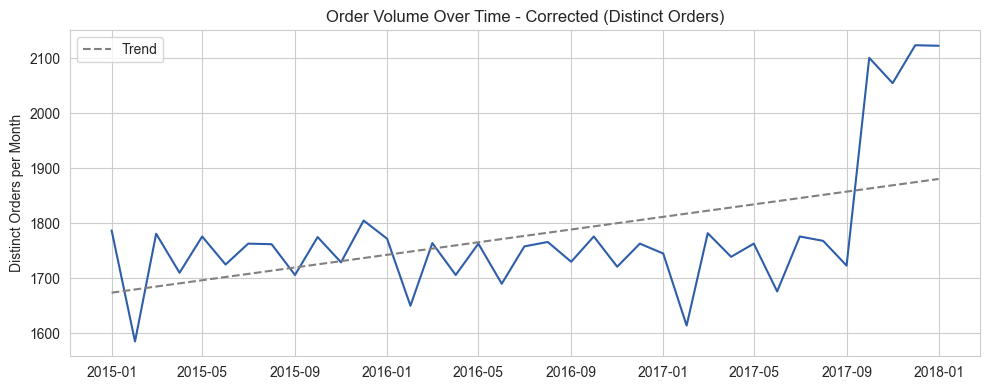

In [34]:
distinct_orders_by_month = (
    df.groupby(df["order date (DateOrders)"].dt.to_period("M"))["Order Id"]
    .nunique()
    .rename("distinct_orders")
    .reset_index()
)
distinct_orders_by_month.columns = ["month", "distinct_orders"]
distinct_orders_by_month["month_ts"] = distinct_orders_by_month["month"].dt.to_timestamp()
distinct_orders_by_month.to_csv(os.path.join(OUTPUT_DIR, "distinct_orders_by_month_corrected.csv"), index=False)

plt.figure(figsize=(10, 4))
plt.plot(distinct_orders_by_month["month_ts"], distinct_orders_by_month["distinct_orders"], color="#2E5EAA")

# Linear trend line: convert dates to a plain numeric axis (days since first month)
# so polyfit can fit a straight line, then map the fitted values back onto the date axis
x_numeric = (distinct_orders_by_month["month_ts"] - distinct_orders_by_month["month_ts"].min()).dt.days
slope, intercept = np.polyfit(x_numeric, distinct_orders_by_month["distinct_orders"], deg=1)
trend_values = slope * x_numeric + intercept

plt.plot(distinct_orders_by_month["month_ts"], trend_values, color="gray", linestyle="--", linewidth=1.5, label="Trend")

plt.title("Order Volume Over Time - Corrected (Distinct Orders)")
plt.ylabel("Distinct Orders per Month")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "orders_over_time_corrected.png"), dpi=150)
plt.show()

The corrected chart tells a very different story from the naive one: distinct order volume held steady around 1,700-1,800/month for nearly the entire period, and if anything *increased* to roughly 2,050-2,150/month in the final few months, the opposite conclusion from the original chart.

#### Step 4: Rule out truncation as an alternative explanation for the uptick

Before treating the late-period increase as a real finding, it's worth checking whether the final months might have incomplete data; e.g. if the dataset were cut off mid-month, that could itself distort the comparison. Checking the maximum day-of-month reached in each month confirms whether every month runs its full length.

In [35]:
df["day_of_month"] = df["order date (DateOrders)"].dt.day

max_day_by_month = (
    df.groupby(df["order date (DateOrders)"].dt.to_period("M"))["day_of_month"]
    .max()
    .rename("max_day_observed")
    .reset_index()
)
max_day_by_month.columns = ["month", "max_day_observed"]
max_day_by_month["days_in_month"] = max_day_by_month["month"].dt.days_in_month
max_day_by_month["complete"] = max_day_by_month["max_day_observed"] == max_day_by_month["days_in_month"]

max_day_by_month.tail(6)

,month,max_day_observed,days_in_month,complete
31,2017-08,31,31,True
32,2017-09,30,30,True
33,2017-10,31,31,True
34,2017-11,30,30,True
35,2017-12,31,31,True
36,2018-01,31,31,True


Every month in the dataset including October, November, and December 2017 and January 2018, shows a maximum observed day exactly matching that month's real calendar length (28/29 for February, 30 for the 30-day months, 31 for the rest). No month is truncated.

**Conclusion:** the ~20% increase in distinct orders during the final months of the dataset is a genuine pattern, verified two independent ways (corrected measurement + confirmed data completeness), not an artifact of either row granularity or missing data.

## 7. Predictive Model (Late Delivery Risk)

**Avoiding data leakage:** `Days for shipping (real)`, `Delivery Status`, and `shipping date (DateOrders)` are only known *after* an order ships, and `Late_delivery_risk` is calculated directly from them. Including them as features would let the model "cheat." A real prediction model can only use information known at **order time**.

In [36]:
target = "Late_delivery_risk"

feature_cols = [
    "Days for shipment (scheduled)", "Shipping Mode", "Order Region", "Market",
    "Customer Segment", "Category Name", "Order Item Quantity", "Sales",
    "Order Item Discount Rate", "Product Price", "order_month", "order_dow",
]

model_df = df[feature_cols + [target]].dropna()

X = model_df[feature_cols]
y = model_df[target]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)],
    remainder="passthrough",
)

clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1 score:  {f1_score(y_test, y_pred):.3f}")
print()
print(classification_report(y_test, y_pred))

Accuracy:  0.701
Precision: 0.835
Recall:    0.568
F1 score:  0.676

              precision    recall  f1-score   support

           0       0.62      0.86      0.72     16308
           1       0.83      0.57      0.68     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.72      0.70     36104
weighted avg       0.74      0.70      0.70     36104



### Feature importance

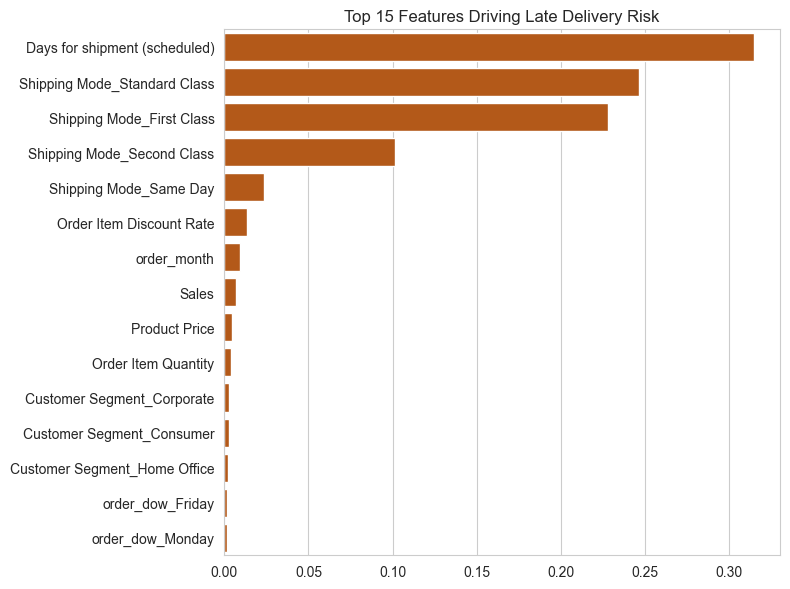

In [37]:
ohe = clf.named_steps["preprocess"].named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = list(ohe_feature_names) + numeric_cols

importances = clf.named_steps["model"].feature_importances_
feat_imp = (
    pd.DataFrame({"feature": all_feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
)
feat_imp.to_csv(os.path.join(OUTPUT_DIR, "feature_importance.csv"), index=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=feat_imp, y="feature", x="importance", color="#CC5500")
plt.title("Top 15 Features Driving Late Delivery Risk")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "feature_importance.png"), dpi=150)
plt.show()

## 8. Save Cleaned Dataset

In [38]:
cleaned_path = os.path.join(OUTPUT_DIR, "DataCo_cleaned.csv")
df.to_csv(cleaned_path, index=False)
print(f"Cleaned dataset saved to: {cleaned_path}")
print(f"All CSVs and charts saved to: {OUTPUT_DIR}")

Cleaned dataset saved to: C:\Projects\DataCo Project\outputs\DataCo_cleaned.csv
All CSVs and charts saved to: C:\Projects\DataCo Project\outputs


## Next steps
- Imported the CSVs in `outputs/` into Tableau to build the interactive dashboard. *Note that `distinct_orders_by_month_corrected.csv` should be used for any order-volume-over-time visual, not the naive row-count version.
- Use the PNGs in `outputs/charts/` for the GitHub README and LinkedIn post. The naive-vs-corrected order volume comparison is the strongest visual story in this project and worth leading with.
- Write up the key findings and business takeaway in the README, including the data quality investigation as its own highlighted section.